# 开盘买入卖出策略回测

策略流程:
1. 每周第一个交易日，使用前一交易日 `amount >= 1000万`、`total_mv >= 10亿` 筛选股票。
2. 从候选中按市值升序选最小的 50 只作为底仓。
3. 每个交易日读取 `09:24:50` 之前最后一个集合竞价快照，计算相对昨收涨跌幅。
4. 开盘买入涨跌幅最小的 10 只，同时卖出涨跌幅最大的 10 只。
5. 收盘反向平仓，恢复到底仓。
这份回测代码 run_open_auction_hedge_strategy.py
  实现了一个结合周度小市值底仓与日内集合竞价对冲的量化策略。其核心逻辑是利用集合竞价结束前的价格快照来捕捉日内的均值回归机会。

  以下是该回测流程的详细分解：

  1. 策略核心逻辑 (Strategy Logic)
  该策略由两部分组成：
   * 底仓 (Base Portfolio)： 每周一根据市值筛选 50 只小市值股票，持有一周。其收益作为基准收益 (base_return)。
   * 日内对冲 (Intraday Hedge)： 每天开盘时，在底仓股票中进行“多空”操作：
       * 买入 (Long)： 集合竞价表现最差（跌幅最大）的 10 只。
       * 卖出 (Short)： 集合竞价表现最好（涨幅最大）的 10 只。
       * 平仓： 每天收盘时平掉这些增减仓位，恢复到底仓状态。

  ---

  2. 详细执行流程 (Workflow)

  第一阶段：数据加载与预处理
   1. 日线数据加载 (load_combined_panel)： 加载股票的日线价格、成交额（amount）和总市值（total_mv）。
   2. Tick 数据索引 (list_tick_dates)： 扫描指定的 Tick 数据目录，确认哪些交易日拥有高频快照数据。
   3. 确定交易日序列： 取日线数据与 Tick 数据的交集，作为实际可回测的日期。

  第二阶段：周度底仓构建 (build_weekly_holding_map)
   1. 触发调仓： 每周的第一个交易日。
   2. 筛选池：
       * 成交额 $\ge 1000$ 万元且总市值 $\ge 10$ 亿元。
       * 排除非沪深股票及特定代码（如 200/900 开头的 B 股）。
   3. 选股： 按总市值升序排列，取前 50 只最小市值的股票。
   4. 持有： 这一组股票在接下来的整周内保持不变。

  第三阶段：日内信号提取 (extract_auction_snapshot)
  这是该策略最关键的高频部分。对于底仓中的每只股票，程序会读取其当天早盘的快照：
   1. 截断时间： 锁定 09:24:50 之前的最后一条快照（这是集合竞价不可撤单阶段的最后时刻）。
   2. 价格获取： 优先取 lastPrice（最新价），若无则取买卖盘中间价。
   3. 计算涨跌幅： auction_return = 快照价 / 昨收盘价 - 1。这个涨跌幅反映了市场在开盘前对该股的预期。

  第四阶段：策略模拟与收益计算 (simulate_strategy)
  每天对底仓内的股票进行排序：
   1. 信号排序： 按 auction_return 从低到高排序。
   2. 多头信号 (long_signal)： 选取排名最靠前的 10 只（竞价最弱）。计算其从开盘到收盘的超额收益。
   3. 空头信号 (short_signal)： 选取排名最靠后的 10 只（竞价最强）。计算其从开盘到收盘的反向收益。
   4. 交易成本： 在计算 extra_return（超额收益）时，扣除了：
       * 手续费： 买入 0.02%，卖出 0.07%。
       * 滑点： 单边 0.03%。
   5. 总收益组合： strategy_return = base_return（底仓均值） + extra_return（对冲收益均值）。

  第五阶段：绩效评估与输出
   1. 绩效指标 (compute_performance_metrics)： 计算年化收益、夏普比率（Sharpe）、最大回撤等。
   2. 对比分析： 对比“纯小市值底仓”与“底仓+竞价对冲”的表现差异。
   3. 结果固化：
       * 生成 NAV 曲线图 (nav_curve.png)。
       * 保存详细交易记录和每日组合数据。
       * 自动化生成一个 Jupyter Notebook (open_auction_hedge_strategy_research.ipynb) 方便离线查看研究结论。

  ---

  3. 关键函数说明
   * pick_weekly_universe: 实现了小市值选股逻辑。
   * extract_auction_snapshot: 处理 Parquet 格式的 Tick 数据，提取 9:24:50 的关键价格。
   * _long_extra_return / _short_extra_return: 精确计算扣除费率和滑点后的日内波动收益。
   * build_stock_level_panel: 将日线和高频快照整合成一个“大面板”，这是后续回测计算的基础。

  总结
  该流程展示了典型的量化研究闭环：从低频的市值选股（贝塔收益）出发，利用高频 Tick 数据捕捉微观结构上的过度反应或定价偏差（阿尔法收益），并严格考虑了实际交易中的费率成本

## 参数

- `min_amount=10000.0`
- `min_total_mv=100000.0`
- `hold_count=50`
- `trade_count=10`
- `buy_fee=0.0002`
- `sell_fee=0.0007`
- `slippage=0.0003`


In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

repo_root = Path(r'/data1/code_git/tick_data_analysis')
outdir = Path(r'/data1/code_git/tick_data_analysis/backtest/output_open_auction_hedge')
script_path = Path(r'/data1/code_git/tick_data_analysis/backtest/custom_scripts/run_open_auction_hedge_strategy.py')
metrics = json.loads((outdir / 'metrics.json').read_text(encoding='utf-8'))
daily = pd.read_csv(outdir / 'daily_portfolio.csv', parse_dates=['trade_date'])
rebalance = pd.read_csv(outdir / 'weekly_rebalance_log.csv', parse_dates=['trade_date', 'prev_trade_date'])
stock = pd.read_parquet(outdir / 'stock_level_results.parquet')
print(metrics)
daily.head()


{'config': {'min_amount': 10000.0, 'min_total_mv': 100000.0, 'hold_count': 50, 'trade_count': 10, 'buy_fee': 0.0002, 'sell_fee': 0.0007, 'slippage': 0.0003, 'cash': 10000000.0}, 'trade_days': 140, 'avg_hold_count': 49.84285714285714, 'avg_valid_signal_count': 48.464285714285715, 'buy_trades_total': 1400, 'sell_trades_total': 1400, 'annual_extra_return': 0.10588567781064073, 'baseline': {'initial_cash': 10000000.0, 'final_value': 13384048.148475116, 'observations': 140, 'total_return': 0.3384048148475116, 'annual_return': 0.689886290035568, 'annual_volatility': 0.19449562013915409, 'downside_volatility': 0.12979363226296303, 'sharpe': 2.7978453347978, 'sortino': 4.192568263614403, 'calmar': 5.551780690882512, 'max_drawdown_pct': 12.426396654474182, 'max_drawdown_duration_days': 44.0, 'win_days': 82.0, 'loss_days': 58.0, 'flat_days': 0.0, 'win_rate': 0.5857142857142857, 'loss_rate': 0.4142857142857143, 'avg_win_daily_return': 0.010484450175241486, 'avg_loss_daily_return': -0.009610499831

,trade_date,hold_count,valid_signal_count,buy_count,sell_count,base_return,extra_return,strategy_return,avg_buy_signal_return,avg_sell_signal_return
0,2025-08-01,50,50,10,10,0.012143,0.000713,0.012856,-0.011310,0.006783
1,2025-08-04,50,48,10,10,0.012422,-0.001220,0.011202,-0.012148,0.011818
2,2025-08-05,49,47,10,10,0.017837,-0.002323,0.015514,-0.014209,0.011423
3,2025-08-06,49,47,10,10,0.015836,0.000548,0.016384,-0.014209,0.011423
4,2025-08-07,49,47,10,10,0.001555,0.000548,0.002103,-0.014209,0.011423


## 最近 20 个交易日组合结果

| trade_date   |   hold_count |   valid_signal_count |   buy_count |   sell_count |   base_return |   extra_return |   strategy_return |   avg_buy_signal_return |   avg_sell_signal_return |
|:-------------|-------------:|---------------------:|------------:|-------------:|--------------:|---------------:|------------------:|------------------------:|-------------------------:|
| 2026-01-29   |           49 |                   48 |          10 |           10 |     -0.006089 |       0.00259  |         -0.003499 |               -0.036799 |                 0.013122 |
| 2026-01-30   |           49 |                   49 |          10 |           10 |      0.01567  |      -0.001647 |          0.014023 |               -0.029098 |                 0.01952  |
| 2026-02-02   |           50 |                   49 |          10 |           10 |     -0.000464 |      -0.001952 |         -0.002416 |               -0.038918 |                 0.025273 |
| 2026-02-03   |           50 |                   49 |          10 |           10 |      0.011327 |       0.001206 |          0.012533 |               -0.026541 |                 0.021789 |
| 2026-02-04   |           50 |                   49 |          10 |           10 |      0.007816 |      -0.001516 |          0.0063   |               -0.021603 |                 0.020715 |
| 2026-02-05   |           50 |                   48 |          10 |           10 |      0.005185 |       0.003839 |          0.009024 |               -0.030265 |                 0.015892 |
| 2026-02-06   |           50 |                   48 |          10 |           10 |      0.006848 |       0.001888 |          0.008736 |               -0.031424 |                 0.01652  |
| 2026-02-10   |           50 |                   49 |          10 |           10 |      0.001118 |      -0.000826 |          0.000293 |               -0.01119  |                 0.017847 |
| 2026-02-11   |           50 |                   48 |          10 |           10 |     -0.006654 |       0.000366 |         -0.006288 |               -0.019406 |                 0.020329 |
| 2026-02-12   |           50 |                   45 |          10 |           10 |     -0.01449  |       0.001197 |         -0.013293 |               -0.017275 |                 0.007005 |
| 2026-02-13   |           50 |                   48 |          10 |           10 |     -7.4e-05  |      -0.002158 |         -0.002232 |               -0.025174 |                 0.007947 |
| 2026-02-24   |           49 |                   49 |          10 |           10 |      0.016186 |      -0.003036 |          0.013149 |               -0.024124 |                 0.015962 |
| 2026-02-25   |           49 |                   48 |          10 |           10 |      0.010251 |       0.002086 |          0.012337 |               -0.016482 |                 0.016068 |
| 2026-02-26   |           49 |                   49 |          10 |           10 |     -0.002645 |      -0.000875 |         -0.00352  |               -0.014185 |                 0.017554 |
| 2026-02-27   |           49 |                   47 |          10 |           10 |      0.006383 |       0.000581 |          0.006964 |               -0.023923 |                 0.015567 |
| 2026-03-03   |           50 |                   49 |          10 |           10 |     -0.025719 |       0.002243 |         -0.023476 |               -0.012814 |                 0.013196 |
| 2026-03-04   |           50 |                   50 |          10 |           10 |     -0.007313 |       0.002647 |         -0.004665 |               -0.033643 |                 2.4e-05  |
| 2026-03-05   |           50 |                   48 |          10 |           10 |      0.012447 |       0.001798 |          0.014245 |               -0.005199 |                 0.022318 |
| 2026-03-06   |           50 |                   49 |          10 |           10 |      0.027668 |       0.000535 |          0.028202 |               -0.017866 |                 0.008153 |
| 2026-03-09   |           50 |                   50 |          10 |           10 |     -0.010303 |       0.002629 |         -0.007674 |               -0.046511 |                -0.000282 |

## 最近 10 次周调仓记录

| trade_date   | prev_trade_date   |   hold_count | symbols_preview                                                                                     |
|:-------------|:------------------|-------------:|:----------------------------------------------------------------------------------------------------|
| 2025-12-29   | 2025-12-26        |           50 | 600355.SH,600696.SH,605081.SH,300029.SZ,688701.SH,002808.SZ,002848.SZ,688021.SH,002211.SZ,002193.SZ |
| 2026-01-05   | 2025-12-31        |           50 | 688701.SH,600355.SH,605081.SH,002808.SZ,600421.SH,002211.SZ,002193.SZ,688021.SH,300929.SZ,688296.SH |
| 2026-01-12   | 2026-01-09        |           50 | 600696.SH,600355.SH,300029.SZ,688701.SH,600608.SH,605081.SH,002193.SZ,600421.SH,000004.SZ,002808.SZ |
| 2026-01-19   | 2026-01-16        |           50 | 600355.SH,600608.SH,605081.SH,300029.SZ,688701.SH,600421.SH,002808.SZ,002193.SZ,600599.SH,300338.SZ |
| 2026-01-26   | 2026-01-23        |           50 | 300029.SZ,600355.SH,600608.SH,605081.SH,688701.SH,600421.SH,600599.SH,300338.SZ,600365.SH,603789.SH |
| 2026-02-02   | 2026-01-30        |           50 | 300029.SZ,600599.SH,605081.SH,600608.SH,300338.SZ,600365.SH,688701.SH,002211.SZ,300152.SZ,600421.SH |
| 2026-02-09   | 2026-02-06        |           50 | 605081.SH,300029.SZ,600599.SH,002808.SZ,600365.SH,688701.SH,603789.SH,002211.SZ,600243.SH,002872.SZ |
| 2026-02-24   | 2026-02-13        |           50 | 600599.SH,000004.SZ,300029.SZ,600608.SH,605081.SH,300344.SZ,002808.SZ,688701.SH,600243.SH,600421.SH |
| 2026-03-03   | 2026-02-27        |           50 | 300029.SZ,605081.SH,002808.SZ,688701.SH,600365.SH,600421.SH,300338.SZ,600243.SH,002211.SZ,300929.SZ |
| 2026-03-09   | 2026-03-06        |           50 | 300029.SZ,605081.SH,688701.SH,688287.SH,600365.SH,600421.SH,603789.SH,002789.SZ,600243.SH,300338.SZ |

In [ ]:
nav = daily[['trade_date', 'base_return', 'strategy_return']].copy()
nav['baseline_nav'] = (1 + nav['base_return']).cumprod()
nav['strategy_nav'] = (1 + nav['strategy_return']).cumprod()
ax = nav.plot(x='trade_date', y=['baseline_nav', 'strategy_nav'], figsize=(10, 5), grid=True)
ax.set_title('Baseline vs Auction Hedge')
ax.set_ylabel('NAV')
plt.show()


In [ ]:
signal_summary = {
    'trade_days': len(daily),
    'avg_hold_count': daily['hold_count'].mean(),
    'avg_valid_signal_count': daily['valid_signal_count'].mean(),
    'buy_trades_total': daily['buy_count'].sum(),
    'sell_trades_total': daily['sell_count'].sum(),
    'avg_extra_return_bp': daily['extra_return'].mean() * 10000,
}
signal_summary


## 核心绩效

- 基线总收益: `0.3384048148475116`
- 策略总收益: `0.41857993910925106`
- 超额总收益: `0.08017512426173945`
- 基线 Sharpe: `2.7978453347978`
- 策略 Sharpe: `3.261588143435436`
- Sharpe 差值: `0.4637428086376363`
- 年化超额收益: `0.10588567781064073`


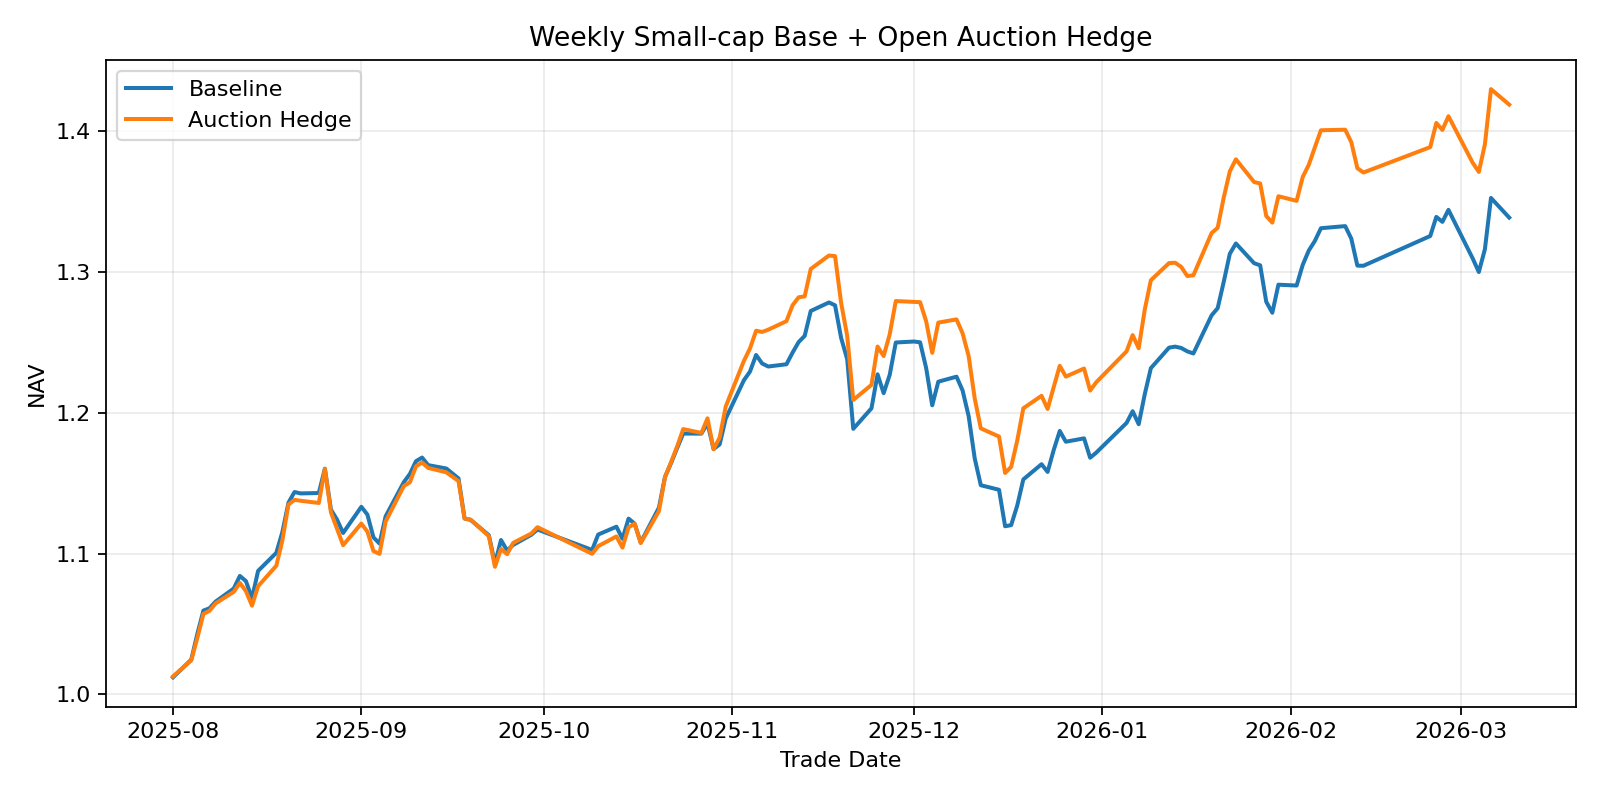

In [3]:
display(Image(filename=str(outdir / 'nav_curve.png')))
